# Robustness and Negative Controls

This is the final refinement notebook. It does not add a new story; it stress-tests the existing one.

The goal is to answer the skeptical reviewer questions:

- Are direction-only results stronger than shuffled-label directions?
- Are steering and ablation stronger than norm-matched random-vector controls?
- Do the headline metrics have bootstrap confidence intervals?
- Are the held-out test results driven by one test actor?
- Do the expensive causal notebooks expose enough saved outputs to quantify patch-transfer uncertainty?

Run this after notebooks `14` and `15` if you want the patch/mid-transformer sections included. If those outputs are missing, this notebook still runs and clearly marks those optional controls as skipped.


<!-- narrative:16-role -->
## Notebook role in the project

This notebook stress-tests the final claims. It does not add a new mechanism; it asks whether the existing results survive bootstrap uncertainty, null controls, and actor-level sensitivity checks.

**Inputs:** saved outputs from the main classifier, direction analyses, ablation notebook, mid-transformer notebook, and patching notebook.

**Outputs:** bootstrap confidence intervals, shuffled/random control summaries, per-actor sensitivity tables, and report-ready robustness figures.

**How to read it:** this is the credibility layer. It turns a collection of exciting results into a more defensible final project.


In [1]:
from __future__ import annotations

import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/pavannn16/speech-emotion-directions.git"
REPO_NAME = "speech-emotion-directions"
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def running_in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False


IS_COLAB = running_in_colab()
print("Running in Colab:", IS_COLAB)


def run_command(cmd, cwd=None):
    print("+", " ".join(cmd))
    subprocess.check_call(cmd, cwd=str(cwd) if cwd else None)


def ensure_packages():
    pkgs = {
        "yaml": "pyyaml", "pandas": "pandas", "numpy": "numpy",
        "matplotlib": "matplotlib", "seaborn": "seaborn",
        "torch": "torch", "transformers": "transformers",
        "sklearn": "scikit-learn", "scipy": "scipy", "tqdm": "tqdm",
    }
    missing = sorted({p for m, p in pkgs.items() if importlib.util.find_spec(m) is None})
    if missing:
        run_command([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Required packages available.")


def find_local_project_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd / "FinalProject"]:
        c = c.resolve()
        if (c / "configs" / "wav2vec.yaml").exists() and (c / "src").exists():
            return c
    raise FileNotFoundError("Could not find project root.")


def clone_clean(clean_root):
    if clean_root.exists():
        shutil.rmtree(clean_root)
    run_command(["git", "clone", "--depth", "1", REPO_URL, str(clean_root)])
    return clean_root


def prepare_roots():
    rt = Path("/content") / REPO_NAME
    cl = Path("/content") / f"{REPO_NAME}-clean"
    if rt.exists() and (rt / ".git").exists():
        try:
            run_command(["git", "-C", str(rt), "fetch", "origin"])
        except Exception:
            pass
        st = subprocess.run(["git", "-C", str(rt), "status", "--short"], text=True, capture_output=True, check=True).stdout.splitlines()
        ab = subprocess.run(["git", "-C", str(rt), "rev-list", "--left-right", "--count", "HEAD...origin/main"], text=True, capture_output=True, check=False)
        a, b = (0, 0) if ab.returncode != 0 or not ab.stdout.strip() else map(int, ab.stdout.strip().split())
        if not [line for line in st if line.strip()] and a == 0:
            if b > 0:
                try:
                    run_command(["git", "-C", str(rt), "pull", "--ff-only", "origin", "main"])
                    cr = rt
                except Exception:
                    cr = clone_clean(cl)
            else:
                cr = rt
        else:
            cr = clone_clean(cl)
        return rt, cr
    if rt.exists():
        return rt, clone_clean(cl)
    run_command(["git", "clone", "--depth", "1", REPO_URL, str(rt)])
    return rt, rt


ensure_packages()
if IS_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT, CODE_ROOT = prepare_roots()
else:
    PROJECT_ROOT = find_local_project_root()
    CODE_ROOT = PROJECT_ROOT

os.chdir(PROJECT_ROOT)
for r in [str(CODE_ROOT), str(PROJECT_ROOT)]:
    while r in sys.path:
        sys.path.remove(r)
sys.path.insert(0, str(CODE_ROOT))
if str(PROJECT_ROOT) != str(CODE_ROOT):
    sys.path.insert(1, str(PROJECT_ROOT))
for n in [n for n in list(sys.modules) if n == "src" or n.startswith("src.")]:
    del sys.modules[n]
print("Project root:", PROJECT_ROOT)
print("Code root:", CODE_ROOT)


Running in Colab: True
Required packages available.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
+ git -C /content/speech-emotion-directions fetch origin
+ git clone --depth 1 https://github.com/pavannn16/speech-emotion-directions.git /content/speech-emotion-directions-clean
Project root: /content/speech-emotion-directions
Code root: /content/speech-emotion-directions-clean


In [2]:
from pathlib import Path

experiment_name = 'wav2vec_ravdess_speaker_independent_v1'
local_checkpoint_dir = PROJECT_ROOT / 'artifacts' / 'checkpoints' / experiment_name
local_analysis_dir = PROJECT_ROOT / 'artifacts' / 'analysis' / experiment_name
local_output_dir = local_analysis_dir / 'robustness_controls'
local_output_dir.mkdir(parents=True, exist_ok=True)

drive_run_root = Path('/content/drive/MyDrive') / 'speech-emotion-directions' / 'runs' / experiment_name if IS_COLAB else None
drive_checkpoint_dir = drive_run_root / 'checkpoint' if drive_run_root else None
drive_analysis_dir = drive_run_root / 'analysis' if drive_run_root else None
drive_output_dir = drive_analysis_dir / 'robustness_controls' if drive_analysis_dir else None

checkpoint_dir = (
    drive_checkpoint_dir
    if drive_checkpoint_dir is not None and (drive_checkpoint_dir / 'model_state.pt').exists()
    else local_checkpoint_dir
)
analysis_source_dir = (
    drive_analysis_dir
    if drive_analysis_dir is not None and (drive_analysis_dir / 'embedding_arrays.npz').exists()
    else local_analysis_dir
)

required_files = [analysis_source_dir / 'embedding_arrays.npz', analysis_source_dir / 'embedding_metadata.csv']
missing = [str(p) for p in required_files if not p.exists()]
assert not missing, 'Missing analysis inputs: ' + ', '.join(missing)
assert (checkpoint_dir / 'model_state.pt').exists(), f'Missing checkpoint: {checkpoint_dir / "model_state.pt"}'

print('Checkpoint:', checkpoint_dir)
print('Analysis  :', analysis_source_dir)
print('Output    :', local_output_dir)


Checkpoint: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/checkpoint
Analysis  : /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis
Output    : /content/speech-emotion-directions/artifacts/analysis/wav2vec_ravdess_speaker_independent_v1/robustness_controls


In [3]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score

from src.analysis.advanced_analysis import ablate_all_directions, direction_classify
from src.analysis.anthropic_style import build_train_directions_with_controls
from src.analysis.emotion_vectors import (
    build_direction_vectors,
    compute_class_centroids,
    linear_classifier_probabilities,
    load_embedding_artifacts,
)
from src.analysis.extract_embeddings import load_trained_checkpoint

artifacts = load_embedding_artifacts(analysis_source_dir)
metadata = artifacts.metadata.copy()
label_names = list(artifacts.summary['label_names'])
reference_label = 'neutral'
reference_idx = label_names.index(reference_label)
label_ids = artifacts.true_label_ids
split_array = metadata['split'].to_numpy()
train_mask = split_array == 'train'
val_mask = split_array == 'val'
test_mask = split_array == 'test'

test_labels = label_ids[test_mask]
test_metadata = metadata[test_mask].reset_index(drop=True).copy()
final_layer_idx = artifacts.layer_embeddings.shape[1] - 1
final_embeddings = artifacts.layer_embeddings[:, final_layer_idx]
test_embeddings = final_embeddings[test_mask]

centered_embeddings, centered_centroids, centered_directions = build_train_directions_with_controls(
    embeddings=final_embeddings,
    metadata=metadata,
    label_ids=label_ids,
    label_names=label_names,
    reference_label=reference_label,
)
raw_centroids = compute_class_centroids(final_embeddings[train_mask], label_ids[train_mask], len(label_names))
raw_directions = build_direction_vectors(raw_centroids, reference_idx)

checkpoint = load_trained_checkpoint(checkpoint_dir)
classifier_weight = checkpoint.model.classifier.weight.detach().cpu().numpy()
classifier_bias = checkpoint.model.classifier.bias.detach().cpu().numpy()

trained_preds = artifacts.pred_label_ids[test_mask]
direction_preds = direction_classify(centered_embeddings[test_mask], centered_directions, reference_idx)
base_probs = linear_classifier_probabilities(test_embeddings, classifier_weight, classifier_bias)
base_preds = base_probs.argmax(axis=1)

print(f'Test samples: {len(test_labels)}')
print(f'Labels: {label_names}')
print(f'Final layer index: {final_layer_idx}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test samples: 208
Labels: ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']
Final layer index: 12


## 1. Bootstrap Confidence Intervals

We bootstrap over held-out test examples. For paired effects such as ablation drop, each bootstrap sample reuses the same sampled indices for the baseline and intervention predictions.


<!-- narrative:16-bootstrap -->
## Bootstrap confidence intervals

Point estimates alone can look stronger than they are. Bootstrapping over held-out examples gives uncertainty intervals for macro F1, steering effects, ablation drops, and patching effects.


In [4]:
RNG_SEED = 42
BOOTSTRAP_DRAWS = 1000
rng = np.random.default_rng(RNG_SEED)


def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=BOOTSTRAP_DRAWS, rng=rng):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        values.append(metric_fn(y_true[idx], y_pred[idx]))
    values = np.asarray(values, dtype=float)
    point = metric_fn(y_true, y_pred)
    return point, float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))


def bootstrap_mean_ci(values, n_boot=BOOTSTRAP_DRAWS, rng=rng):
    values = np.asarray(values, dtype=float)
    boots = []
    n = len(values)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots.append(float(values[idx].mean()))
    boots = np.asarray(boots)
    return float(values.mean()), float(np.quantile(boots, 0.025)), float(np.quantile(boots, 0.975))


def bootstrap_macro_f1_delta_ci(y_true, pred_before, pred_after, n_boot=BOOTSTRAP_DRAWS, rng=rng):
    y_true = np.asarray(y_true)
    pred_before = np.asarray(pred_before)
    pred_after = np.asarray(pred_after)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        before = f1_score(y_true[idx], pred_before[idx], average='macro', zero_division=0)
        after = f1_score(y_true[idx], pred_after[idx], average='macro', zero_division=0)
        values.append(after - before)
    values = np.asarray(values, dtype=float)
    point = f1_score(y_true, pred_after, average='macro', zero_division=0) - f1_score(y_true, pred_before, average='macro', zero_division=0)
    return float(point), float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))


def metric_accuracy(y_true, y_pred):
    return float(accuracy_score(y_true, y_pred))


def metric_macro_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, average='macro', zero_division=0))

# Real all-direction ablation using the same raw final-layer setup as notebook 09.
real_all_ablated = ablate_all_directions(test_embeddings, raw_directions, reference_idx)
real_all_ablated_probs = linear_classifier_probabilities(real_all_ablated, classifier_weight, classifier_bias)
real_all_ablated_preds = real_all_ablated_probs.argmax(axis=1)

# Final-layer steering per sample/target for a bootstrap CI on mean delta target probability.
STEERING_ALPHA = 0.5
steering_deltas = []
for target_idx, target_label in enumerate(label_names):
    if target_idx == reference_idx:
        continue
    steered = test_embeddings + STEERING_ALPHA * raw_directions[target_idx][None, :]
    steered_probs = linear_classifier_probabilities(steered, classifier_weight, classifier_bias)
    steering_deltas.extend((steered_probs[:, target_idx] - base_probs[:, target_idx]).tolist())
steering_deltas = np.asarray(steering_deltas)

ci_rows = []
for name, preds in [('trained_head', trained_preds), ('direction_prototype_controlled', direction_preds)]:
    for metric_name, metric_fn in [('accuracy', metric_accuracy), ('macro_f1', metric_macro_f1)]:
        point, lo, hi = bootstrap_metric_ci(test_labels, preds, metric_fn)
        ci_rows.append({'quantity': name, 'metric': metric_name, 'point': point, 'ci_low': lo, 'ci_high': hi})

point, lo, hi = bootstrap_macro_f1_delta_ci(test_labels, base_preds, real_all_ablated_preds)
ci_rows.append({'quantity': 'real_remove_all_direction_ablation', 'metric': 'macro_f1_delta_vs_baseline', 'point': point, 'ci_low': lo, 'ci_high': hi})

point, lo, hi = bootstrap_mean_ci(steering_deltas)
ci_rows.append({'quantity': 'final_layer_real_direction_steering', 'metric': f'mean_delta_target_prob_alpha_{STEERING_ALPHA}', 'point': point, 'ci_low': lo, 'ci_high': hi})

bootstrap_ci_df = pd.DataFrame(ci_rows)
bootstrap_ci_df.to_csv(local_output_dir / 'bootstrap_confidence_intervals.csv', index=False)
display(bootstrap_ci_df.round(4))


,quantity,metric,point,ci_low,ci_high
0,trained_head,accuracy,0.8365,0.7885,0.8846
1,trained_head,macro_f1,0.8237,0.7688,0.8762
2,direction_prototype_controlled,accuracy,0.8413,0.7885,0.8894
3,direction_prototype_controlled,macro_f1,0.8301,0.7703,0.8796
4,real_remove_all_direction_ablation,macro_f1_delta_vs_baseline,-0.2889,-0.3395,-0.2487
5,final_layer_real_direction_steering,mean_delta_target_prob_alpha_0.5,0.1921,0.1800,0.2043


## 2. Shuffled-Label and Random-Vector Negative Controls

These controls preserve embedding dimensionality, vector norms, class counts, and the classifier head. What changes is whether the directions carry real emotion structure.


<!-- narrative:16-negative-controls -->
## Shuffled-label and random-vector controls

These controls preserve parts of the data geometry while breaking the emotion-specific structure. If they fail while real directions work, the result is more likely to be emotion-specific rather than a generic vector artifact.


In [5]:
CONTROL_DRAWS = 100
rng = np.random.default_rng(RNG_SEED)


def norm_matched_random_directions(real_directions, reference_idx, rng):
    random_dirs = rng.normal(size=real_directions.shape).astype(np.float32)
    random_dirs[reference_idx] = 0.0
    real_norms = np.linalg.norm(real_directions, axis=1, keepdims=True)
    random_norms = np.linalg.norm(random_dirs, axis=1, keepdims=True)
    random_dirs = random_dirs / np.clip(random_norms, 1e-12, None) * real_norms
    random_dirs[reference_idx] = 0.0
    return random_dirs

real_direction_f1 = metric_macro_f1(test_labels, direction_preds)
real_steering_mean_delta = float(steering_deltas.mean())
real_ablation_delta = metric_macro_f1(test_labels, real_all_ablated_preds) - metric_macro_f1(test_labels, base_preds)

control_rows = []
for draw in range(CONTROL_DRAWS):
    # Shuffled-label prototype directions.
    shuffled_train_labels = label_ids[train_mask].copy()
    rng.shuffle(shuffled_train_labels)
    shuffled_centroids = compute_class_centroids(centered_embeddings[train_mask], shuffled_train_labels, len(label_names))
    shuffled_directions = build_direction_vectors(shuffled_centroids, reference_idx)
    shuffled_preds = direction_classify(centered_embeddings[test_mask], shuffled_directions, reference_idx)
    control_rows.append({
        'draw': draw,
        'control_family': 'shuffled_label_direction_classifier',
        'metric': 'macro_f1',
        'value': metric_macro_f1(test_labels, shuffled_preds),
        'real_value': real_direction_f1,
    })

    # Norm-matched random steering.
    random_dirs = norm_matched_random_directions(raw_directions, reference_idx, rng)
    random_steering_deltas = []
    for target_idx in range(len(label_names)):
        if target_idx == reference_idx:
            continue
        steered = test_embeddings + STEERING_ALPHA * random_dirs[target_idx][None, :]
        steered_probs = linear_classifier_probabilities(steered, classifier_weight, classifier_bias)
        random_steering_deltas.extend((steered_probs[:, target_idx] - base_probs[:, target_idx]).tolist())
    control_rows.append({
        'draw': draw,
        'control_family': 'norm_matched_random_steering',
        'metric': f'mean_delta_target_prob_alpha_{STEERING_ALPHA}',
        'value': float(np.mean(random_steering_deltas)),
        'real_value': real_steering_mean_delta,
    })

    # Norm-matched random ablation.
    random_ablated = ablate_all_directions(test_embeddings, random_dirs, reference_idx)
    random_probs = linear_classifier_probabilities(random_ablated, classifier_weight, classifier_bias)
    random_preds = random_probs.argmax(axis=1)
    control_rows.append({
        'draw': draw,
        'control_family': 'norm_matched_random_ablation',
        'metric': 'macro_f1_delta_vs_baseline',
        'value': metric_macro_f1(test_labels, random_preds) - metric_macro_f1(test_labels, base_preds),
        'real_value': real_ablation_delta,
    })

negative_control_df = pd.DataFrame(control_rows)
negative_control_df.to_csv(local_output_dir / 'negative_control_draws.csv', index=False)

summary_rows = []
for (family, metric), group in negative_control_df.groupby(['control_family', 'metric']):
    real_value = float(group['real_value'].iloc[0])
    if 'ablation' in family:
        tail_fraction = float((group['value'] <= real_value).mean())
        tail_label = 'fraction_null_as_or_more_damaging'
    else:
        tail_fraction = float((group['value'] >= real_value).mean())
        tail_label = 'fraction_null_as_or_more_positive'
    summary_rows.append({
        'control_family': family,
        'metric': metric,
        'real_value': real_value,
        'null_mean': float(group['value'].mean()),
        'null_ci_low': float(group['value'].quantile(0.025)),
        'null_ci_high': float(group['value'].quantile(0.975)),
        tail_label: tail_fraction,
    })
negative_control_summary_df = pd.DataFrame(summary_rows)
negative_control_summary_df.to_csv(local_output_dir / 'negative_control_summary.csv', index=False)
display(negative_control_summary_df.round(4))


,control_family,metric,real_value,null_mean,null_ci_low,null_ci_high,fraction_null_as_or_more_damaging,fraction_null_as_or_more_positive
0,norm_matched_random_ablation,macro_f1_delta_vs_baseline,-0.2889,0.0002,0.0000,0.0038,0.0,NaN
1,norm_matched_random_steering,mean_delta_target_prob_alpha_0.5,0.1921,0.0002,-0.0031,0.0037,NaN,0.0
2,shuffled_label_direction_classifier,macro_f1,0.8301,0.1524,0.0138,0.3742,NaN,0.0


## 3. Per-Test-Actor Sensitivity

The test set contains actors `21` through `24`. This check verifies whether the main conclusions depend on one unusually easy or hard actor.


<!-- narrative:16-actor-sensitivity -->
## Per-test-actor sensitivity

The held-out test set contains actors 21 through 24. This check asks whether one actor is driving the result. A robust pattern should hold reasonably across all held-out actors.


,actor_id,n,trained_accuracy,trained_macro_f1,direction_accuracy,direction_macro_f1,ablation_macro_f1_delta
0,21,52,0.8654,0.8529,0.8846,0.8771,-0.2075
1,22,52,0.8077,0.7832,0.7885,0.7677,-0.2466
2,23,52,0.8269,0.7985,0.8269,0.7985,-0.4353
3,24,52,0.8462,0.8519,0.8654,0.8725,-0.3360


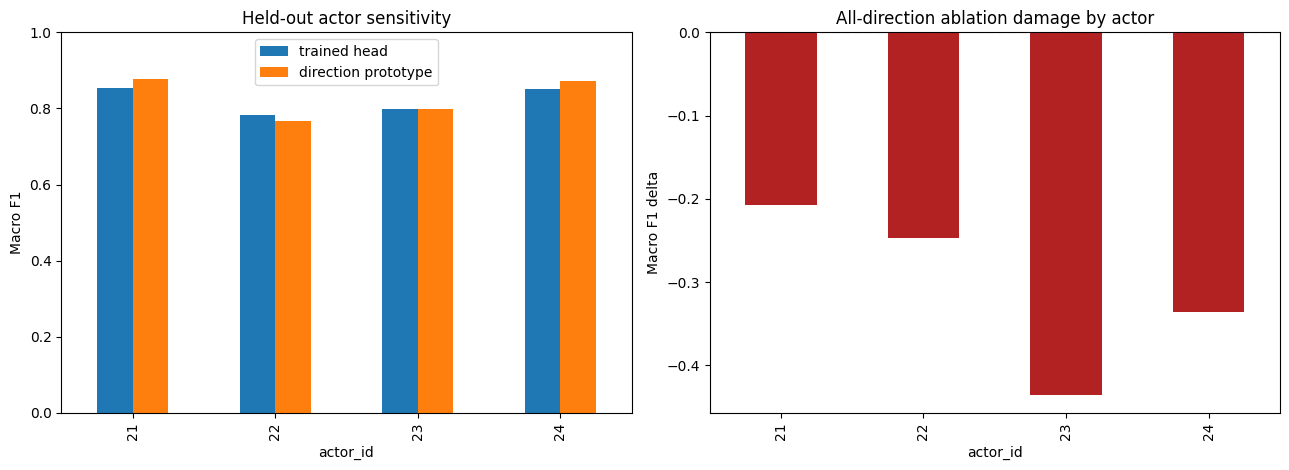

In [6]:
actor_rows = []
test_actor_ids = test_metadata['actor_id'].astype(str).to_numpy()
for actor_id in sorted(pd.unique(test_actor_ids)):
    mask = test_actor_ids == actor_id
    y = test_labels[mask]
    actor_rows.append({
        'actor_id': actor_id,
        'n': int(mask.sum()),
        'trained_accuracy': metric_accuracy(y, trained_preds[mask]),
        'trained_macro_f1': metric_macro_f1(y, trained_preds[mask]),
        'direction_accuracy': metric_accuracy(y, direction_preds[mask]),
        'direction_macro_f1': metric_macro_f1(y, direction_preds[mask]),
        'ablation_macro_f1_delta': metric_macro_f1(y, real_all_ablated_preds[mask]) - metric_macro_f1(y, base_preds[mask]),
    })

actor_sensitivity_df = pd.DataFrame(actor_rows)
actor_sensitivity_df.to_csv(local_output_dir / 'per_test_actor_sensitivity.csv', index=False)
display(actor_sensitivity_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
actor_sensitivity_df.plot(x='actor_id', y=['trained_macro_f1', 'direction_macro_f1'], kind='bar', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Held-out actor sensitivity')
axes[0].legend(['trained head', 'direction prototype'])

actor_sensitivity_df.plot(x='actor_id', y='ablation_macro_f1_delta', kind='bar', ax=axes[1], color='firebrick', legend=False)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_ylabel('Macro F1 delta')
axes[1].set_title('All-direction ablation damage by actor')
plt.tight_layout()
plt.savefig(local_output_dir / 'per_test_actor_sensitivity.png', dpi=220)
plt.show()


## 4. Causal Output Uncertainty from Notebooks 14 and 15

This section reads saved CSV outputs from the expensive causal notebooks when available. It adds uncertainty estimates for patch transfer and records the mid-transformer random-vector control summaries.


<!-- narrative:16-expensive-outputs -->
## Pulling in expensive causal outputs

The mid-transformer and activation-patching notebooks are expensive to rerun. This section reads their saved CSV outputs so the robustness notebook can summarize uncertainty without repeating all forward-hook experiments.


In [7]:
def resolve_analysis_file(relative_path: str) -> Path | None:
    candidates = []
    if drive_analysis_dir is not None:
        candidates.append(drive_analysis_dir / relative_path)
    candidates.append(local_analysis_dir / relative_path)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

causal_rows = []

patch_path = resolve_analysis_file('activation_patching/experiment_1_patch_sweep.csv')
if patch_path is None:
    print('Activation patching sweep not found; skipping patch-transfer CIs.')
else:
    patch_df = pd.read_csv(patch_path)
    agg = patch_df.groupby('layer_index')['delta_p_src'].mean()
    best_layer = int(agg.idxmax())
    best_df = patch_df[patch_df['layer_index'] == best_layer].copy()
    point, lo, hi = bootstrap_mean_ci(best_df['delta_p_src'].to_numpy())
    causal_rows.append({'quantity': 'activation_patch_best_layer_delta_p_src', 'layer_index': best_layer, 'metric': 'mean_delta_p_src', 'point': point, 'ci_low': lo, 'ci_high': hi})
    point, lo, hi = bootstrap_mean_ci(best_df['flip_to_src'].astype(float).to_numpy())
    causal_rows.append({'quantity': 'activation_patch_best_layer_flip_rate', 'layer_index': best_layer, 'metric': 'flip_rate', 'point': point, 'ci_low': lo, 'ci_high': hi})
    print(f'Patch-transfer CIs computed from: {patch_path}')

patch_control_path = resolve_analysis_file('activation_patching/experiment_6_patch_controls_summary.csv')
if patch_control_path is not None:
    patch_control_summary = pd.read_csv(patch_control_path)
    patch_control_summary.to_csv(local_output_dir / 'copied_patch_control_summary.csv', index=False)
    print(f'Patch control summary found: {patch_control_path}')
    display(patch_control_summary.round(4))
else:
    print('Patch control summary not found yet. Run notebook 15 after the new control section to create it.')

mid_control_path = resolve_analysis_file('mid_transformer_causal_trace/random_vector_sufficiency_control_summary.csv')
if mid_control_path is not None:
    mid_control_summary = pd.read_csv(mid_control_path)
    mid_control_summary.to_csv(local_output_dir / 'copied_mid_random_vector_control_summary.csv', index=False)
    print(f'Mid-transformer random-vector control summary found: {mid_control_path}')
    display(mid_control_summary.round(4))
else:
    print('Mid-transformer random-vector control summary not found yet. Run notebook 14 after the new control section to create it.')

causal_ci_df = pd.DataFrame(causal_rows)
causal_ci_df.to_csv(local_output_dir / 'causal_output_confidence_intervals.csv', index=False)
if not causal_ci_df.empty:
    display(causal_ci_df.round(4))


Patch-transfer CIs computed from: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis/activation_patching/experiment_1_patch_sweep.csv
Patch control summary found: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis/activation_patching/experiment_6_patch_controls_summary.csv


,intervention,count,mean_delta_p_src,median_delta_p_src,flip_rate
0,same_emotion_different_context_patch,640,0.7328,0.9599,0.8078
1,full_same_context_patch,640,0.6796,0.9385,0.7562
2,direction_component_patch,640,0.6395,0.8967,0.7266
3,orthogonal_residual_patch,640,0.0533,0.0015,0.1094
4,self_patch_negative_control,640,0.0002,0.0000,0.0531
5,random_source_negative_control,640,-0.0146,-0.0002,0.0406


Mid-transformer random-vector control summary found: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis/mid_transformer_causal_trace/random_vector_sufficiency_control_summary.csv


,target_label,real_delta_target_prob_all,random_mean_delta,random_q05_delta,random_q95_delta,fraction_random_ge_real
0,angry,0.2991,0.0023,-0.0096,0.0126,0.0
1,disgust,0.2901,-0.0057,-0.0226,0.0154,0.0
2,fearful,0.3262,-0.0004,-0.0125,0.0171,0.0
3,happy,0.1354,0.0066,-0.0057,0.0214,0.0
4,sad,0.2217,0.0086,-0.0061,0.0205,0.0


,quantity,layer_index,metric,point,ci_low,ci_high
0,activation_patch_best_layer_delta_p_src,11,mean_delta_p_src,0.6796,0.6475,0.7092
1,activation_patch_best_layer_flip_rate,11,flip_rate,0.7562,0.7219,0.7891


## 5. Visual Summary

These plots are intended for a final appendix/control slide. The red line is the real result; the gray distributions are null controls.


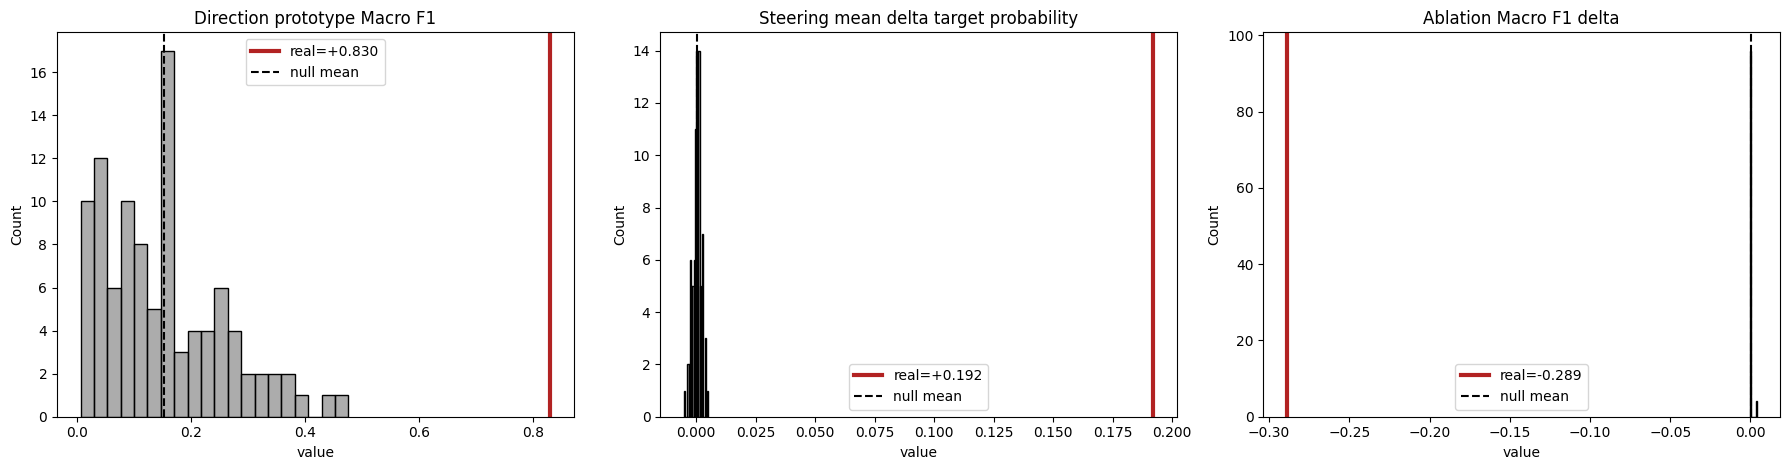

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

plot_specs = [
    ('shuffled_label_direction_classifier', 'macro_f1', real_direction_f1, 'Direction prototype Macro F1'),
    ('norm_matched_random_steering', f'mean_delta_target_prob_alpha_{STEERING_ALPHA}', real_steering_mean_delta, 'Steering mean delta target probability'),
    ('norm_matched_random_ablation', 'macro_f1_delta_vs_baseline', real_ablation_delta, 'Ablation Macro F1 delta'),
]
for ax, (family, metric, real_value, title) in zip(axes, plot_specs):
    subset = negative_control_df[(negative_control_df['control_family'] == family) & (negative_control_df['metric'] == metric)]
    sns.histplot(subset['value'], bins=20, color='gray', alpha=0.65, ax=ax)
    ax.axvline(real_value, color='firebrick', linewidth=3, label=f'real={real_value:+.3f}')
    ax.axvline(subset['value'].mean(), color='black', linestyle='--', label='null mean')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(local_output_dir / 'negative_control_summary_panels.png', dpi=220)
plt.show()


<!-- narrative:16-summary -->
## Final robustness summary

This final summary is designed for the report and presentation. It collects the evidence that the emotion-vector effects survive null baselines and are not driven by a single actor or one fragile metric.


In [9]:
summary = {
    'bootstrap_confidence_intervals': bootstrap_ci_df.to_dict(orient='records'),
    'negative_control_summary': negative_control_summary_df.to_dict(orient='records'),
    'per_test_actor_sensitivity': actor_sensitivity_df.to_dict(orient='records'),
    'causal_output_confidence_intervals': causal_ci_df.to_dict(orient='records') if 'causal_ci_df' in globals() else [],
}
summary_path = local_output_dir / 'robustness_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print('Wrote:', summary_path)

if IS_COLAB and drive_output_dir is not None:
    if drive_output_dir.exists():
        shutil.rmtree(drive_output_dir)
    drive_output_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(local_output_dir, drive_output_dir)
    print('Backed up to:', drive_output_dir)
elif not IS_COLAB:
    print('Google Drive backup skipped outside Colab.')
else:
    print('Drive output directory is not configured.')

print('\nOutput files:')
for p in sorted(local_output_dir.iterdir()):
    print(f'  {p.name}')


Wrote: /content/speech-emotion-directions/artifacts/analysis/wav2vec_ravdess_speaker_independent_v1/robustness_controls/robustness_summary.json
Backed up to: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis/robustness_controls

Output files:
  bootstrap_confidence_intervals.csv
  causal_output_confidence_intervals.csv
  copied_mid_random_vector_control_summary.csv
  copied_patch_control_summary.csv
  negative_control_draws.csv
  negative_control_summary.csv
  negative_control_summary_panels.png
  per_test_actor_sensitivity.csv
  per_test_actor_sensitivity.png
  robustness_summary.json


## Reading the Robustness Results

Use this notebook to make the final project more research-grade, not more complicated.

A strong final interpretation should look like this:

- The real controlled direction-prototype classifier should sit far above the shuffled-label null distribution.
- Real steering should produce a much more positive target-probability shift than norm-matched random vectors.
- Real all-direction ablation should be more damaging than random all-direction ablation.
- Per-actor metrics should vary, but the conclusion should not depend on a single held-out actor.
- Patch-transfer CIs should show a clearly positive effect at the best patch layer.

If any control is weaker than expected, that does not ruin the project. It simply tells us to phrase the claim more carefully: population emotion directions are useful causal probes, while full hidden-state patches reveal richer pair-specific structure.
